# Simple Linear Regression

Predicting `Salary` from `YearsExperience`. Beyond fitting the line, this notebook checks the fit: test-set error metrics, the fitted equation, and a residual plot.

## Importing the libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

## Importing the dataset

In [2]:
data = pd.read_csv('Salary_Data.csv')
X = data.iloc[:, :-1].values
y = data.iloc[:, -1].values
data.head()

,YearsExperience,Salary
0,1.1,39343.0
1,1.3,46205.0
2,1.5,37731.0
3,2.0,43525.0
4,2.2,39891.0


## Splitting the dataset into the Training set and Test set

In [3]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

## Training the Simple Linear Regression model on the Training set

In [4]:
from sklearn.linear_model import LinearRegression
regressor = LinearRegression()
regressor.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


## Predicting the Test set results

In [5]:
y_pred = regressor.predict(X_test)

## Evaluating the model

A regression line is only useful if it generalizes to unseen data, so this checks the fit on the held-out test set rather than just eyeballing the plot: R² (variance explained), MAE (average absolute dollar error), and RMSE (same units as salary, penalizes larger misses more).

In [6]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f'R² (test set):   {r2:.4f}')
print(f'MAE (test set):  ${mae:,.2f}')
print(f'RMSE (test set): ${rmse:,.2f}')

R² (test set):   0.9882
MAE (test set):  $2,446.17
RMSE (test set): $3,580.98


## The fitted equation

In [7]:
slope = regressor.coef_[0]
intercept = regressor.intercept_
print(f'Salary = {intercept:,.2f} + {slope:,.2f} * YearsExperience')
print(f'\nInterpretation: each additional year of experience is associated with about ${slope:,.0f} more in predicted salary, '
      f'holding this simple single-feature model\'s assumptions fixed.')

Salary = 26,780.10 + 9,312.58 * YearsExperience

Interpretation: each additional year of experience is associated with about $9,313 more in predicted salary, holding this simple single-feature model's assumptions fixed.


## Visualising the Training set results

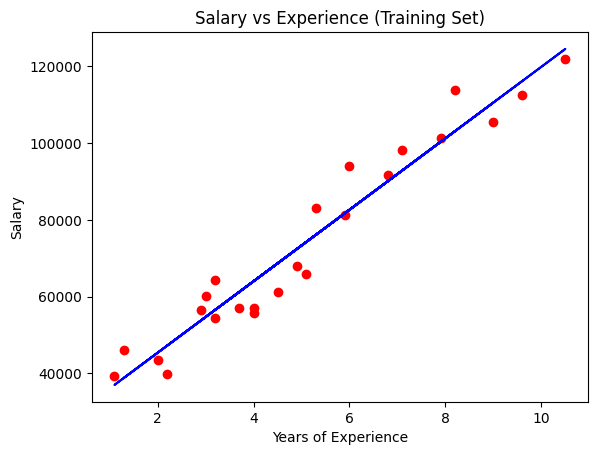

In [8]:
plt.scatter(X_train, y_train, color = 'red')
plt.plot(X_train, regressor.predict(X_train), color = 'blue')
plt.title('Salary vs Experience (Training Set)')
plt.xlabel('Years of Experience')
plt.ylabel('Salary')
plt.show()

## Visualising the Test set results

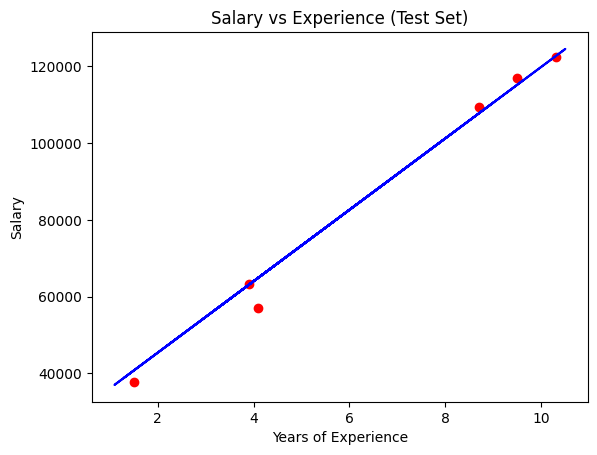

In [9]:
plt.scatter(X_test, y_test, color = 'red')
plt.plot(X_train, regressor.predict(X_train), color = 'blue')
plt.title('Salary vs Experience (Test Set)')
plt.xlabel('Years of Experience')
plt.ylabel('Salary')
plt.show()

## Residual plot

Residuals (actual − predicted) should scatter randomly around zero with no obvious pattern. A curve or funnel shape here would suggest the linear assumption or constant-variance assumption is off — useful to check even when, as here, the relationship is close to linear.

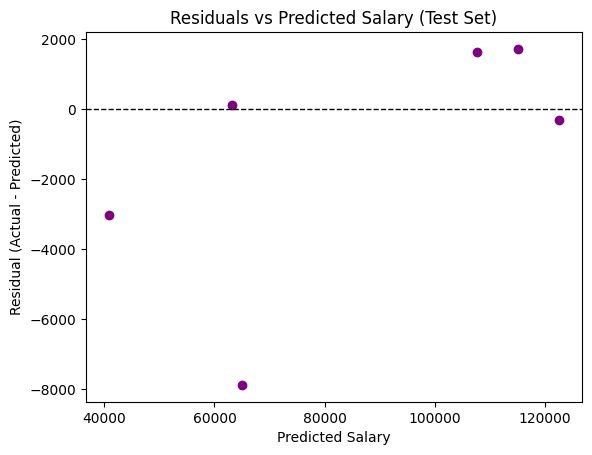

In [10]:
residuals = y_test - y_pred

plt.scatter(y_pred, residuals, color = 'purple')
plt.axhline(y=0, color='black', linestyle='--', linewidth=1)
plt.title('Residuals vs Predicted Salary (Test Set)')
plt.xlabel('Predicted Salary')
plt.ylabel('Residual (Actual - Predicted)')
plt.show()

## Saving the trained model

Persisted for reuse without retraining.

In [11]:
import joblib
import os

os.makedirs('../models', exist_ok=True)
joblib.dump(regressor, '../models/simple_linear_regression.joblib')
print('Saved to ../models/simple_linear_regression.joblib')

Saved to ../models/simple_linear_regression.joblib
